## MSA29HCM - Natural Language Processing - Final Project

### Demo: Simple RAG application using different Vector Space Models

#### Group Information

1. Hồ Nhật Thanh - 25MSA23226
2. Bùi Nguyễn Trúc Như - 25MSA23250
3. Nguyễn Văn Nhật - 25MSA23239

### I. Project Overview

#### 1. Introduction and Objectives
The primary objective of this project is to implement, evaluate, and critically compare three distinct classes of Vector Space Models (VSM)—Sparse, Dense, and Contextual models—within a RAG framework for advanced information extraction tasks. By deconstructing the processing pipelines of each model, this project aims to demonstrate a profound mastery of modern retrieval architectures.

#### 2. Model Architectures and Processing Pipelines
To thoroughly understand and master the retrieval process, this project orchestrates three distinct processing pipelines acting upon a unified, domain-specific corpus (an NLP technical document).

* **Phase 1: Data Ingestion and Chunking**

  The raw document is parsed, cleaned, and systematically divided into manageable text chunks using a sliding window approach (e.g., fixed token length with overlap) to ensure that localized context is preserved across boundaries.

* **Phase 2: Sparse Model Pipeline (Lexical Retrieval - BM25)**
  
  This pipeline represents traditional keyword-based search.

  * *Processing*: The corpus undergoes tokenization and normalization. The system builds an Inverted Index, mapping discrete vocabulary terms to their corresponding chunk IDs.

  * *Retrieval*: Upon receiving a query, the model calculates the Okapi BM25 score based on exact term frequency (TF) and inverse document frequency (IDF). It excels at exact-match lookups but is theoretically blind to semantic meaning.

* **Phase 3: Dense Model Pipeline (Semantic Retrieval - Bi-Encoder)**

  This pipeline addresses the vocabulary mismatch problem using deep learning.

  * *Processing*: Both the document chunks and the incoming query are passed independently through a Transformer-based Bi-Encoder (e.g., Sentence-BERT). The text is compressed into high-dimensional, dense floating-point vectors representing latent semantic meaning.

  * *Retrieval*: The system computes the Cosine Similarity between the query vector and all chunk vectors in the multidimensional space, enabling the retrieval of synonymous and conceptually related information.

* **Phase 4: Single-Stage Cross-Encoder** (Accuracy vs. Computational Cost)

  This phase establishes the ultimate semantic precision baseline using a "naive" single-stage Cross-Encoder approach to empirically demonstrate the trade-off between retrieval accuracy and inference latency.
  
  * *Processing*: The system performs exhaustive, real-time cross-attention between the query and every chunk in the corpus, bypassing pre-computation.
  * *Outcome*: While this eliminates the information loss associated with dense vector embeddings, the $O(L^2)$ quadratic complexity of the Transformer mechanism results in catastrophic latency, rendering it impractical for production.
  
* **Conclusion: The Necessity of Two-Stage Retrieval**

  The project proves that a hybrid architecture is mandatory for real-time systems to balance accuracy and performance:
  
  1. Stage 1 (Retrieval): Uses Dense/Sparse models to quickly filter millions of records down to a small candidate pool (e.g., Top 50) in milliseconds.
  
  2. Stage 2 (Re-ranking): Applies the high-precision Cross-Encoder only to the limited candidates from Stage 1, effectively neutralizing the $O(L^2)$ bottleneck while maintaining analytical depth.

#### 3. Testing Methodology
To empirically validate the theoretical behaviors of these models, a simple software testing framework is established. A curated "Ground Truth" dataset comprising varied test scenarios is executed across all three pipelines. The test cases are strategically categorized to expose the strengths and weaknesses of each architecture:

* **Exact Keyword Queries**: To test Sparse model precision.
* **Synonym and Semantic Queries**: To evaluate the Dense model's linguistic mapping.
* **Complex Contextual Traps**: To challenge Bi-Encoders and prove the necessity of Cross-Encoders.
* **Typo Robustness**: To test tokenizer resilience against malformed inputs.
* **Out-of-Domain Queries**: To verify the system's ability to reject irrelevant information.

#### 4. Comparative Evaluation and Conclusions
The final phase of the project involves a quantitative and qualitative analysis of the test results.

* **Quantitative Metrics**: The performance of each model group is benchmarked using standard statistical retrieval metrics, primarily Mean Reciprocal Rank (MRR), to objectively measure ranking accuracy.

* **Architectural Assessment**: The project will analyze the trade-offs between computational latency, memory footprint, and retrieval precision.

### II. Source code

#### 2.1. Data Ingestion and Chunking

- Load sample documents

In [1]:
# Enable the autoreload extension
%load_ext autoreload
%autoreload 2

In [2]:
import nltk
import json
import data_ingest
import test
import os
import pandas as pd

In [30]:
nlp_data_path = 'data/sample_data/NLP_Architecture-of-meaning.pdf'
noise_data_path = 'data/sample_data/electrical_noise.pdf'

try:
    print("Reading NLP Data...")
    nlp_data_raw = data_ingest.extract_text_from_pdf(nlp_data_path)
    nlp_data = data_ingest.clean_pdf_text(nlp_data_raw)
    print(f"-> Extraction successful. Text length: {len(nlp_data)} characters ({len(nlp_data.split())} words).") 

    print("Reading Noise Data...")
    noise_data_raw = data_ingest.extract_text_from_pdf(noise_data_path)
    noise_data = data_ingest.clean_pdf_text(noise_data_raw)
    print(f"-> Extraction successful. Text length: {len(noise_data)} characters ({len(noise_data.split())} words).") 
except Exception as e:
    print(f"An error occurred: {e}")

Reading NLP Data...
-> Extraction successful. Text length: 24701 characters (3264 words).
Reading Noise Data...
-> Extraction successful. Text length: 2898 characters (381 words).


- Execute chunking documents

In [32]:
# Chunking 2 documents with 3 methods
nlp_sliding_chunks, nlp_semantic_chunks, nlp_paragraph_chunks = data_ingest.document_chunking(nlp_data, source = "NLP_Architecture-of-meaning.pdf")
noise_sliding_chunks, noise_semantic_chunks, noise_paragraph_chunks = data_ingest.document_chunking(noise_data, source = "electrical_noise.pdf")

# Merge chunk objects of 2 documents into 1, we will use the common object in below process
sliding_chunks = nlp_sliding_chunks + noise_sliding_chunks
semantic_chunks = nlp_semantic_chunks + noise_semantic_chunks
paragraph_chunks = nlp_paragraph_chunks + noise_paragraph_chunks


Performing chunking...
-> Split into 27 sliding chunks.
-> Split into 25 semantic chunks.
-> Split into 24 paragraph chunks.

Performing chunking...
-> Split into 3 sliding chunks.
-> Split into 3 semantic chunks.
-> Split into 3 paragraph chunks.


- Save chunks into files

In [33]:
# Sliding chunks
data_ingest.save_chunks_to_json(
        chunks=sliding_chunks,
        output_path="data/chunks_sliding.json",
        metadata={"chunking_method": "sliding_chunks"}
)

# Semantic chunks
data_ingest.save_chunks_to_json(
        chunks=semantic_chunks,
        output_path="data/chunks_semantic.json",
        metadata={"chunking_method": "semantic_chunks"}
)

# Paragraph chunks
data_ingest.save_chunks_to_json(
        chunks=paragraph_chunks,
        output_path="data/chunks_paragraph.json",
        metadata={"chunking_method": "paragraph_chunks"}
)

Successfully saved 30 chunks to data/chunks_sliding.json
Successfully saved 28 chunks to data/chunks_semantic.json
Successfully saved 27 chunks to data/chunks_paragraph.json


In [34]:
eval_path = 'data/eval_dataset.json'

# Load the verified evaluation dataset
with open(eval_path, "r", encoding="utf-8") as f:
    eval_dataset = json.load(f)
print(f"Loaded {len(eval_dataset)} test cases successfully!")

Loaded 20 test cases successfully!


#### 2.2. Sparse Model

In [35]:
import math
import string
import time
from collections import Counter

def simple_tokenizer(text):
    """
    Tokenize and normalize text by converting to lowercase and removing punctuation.
    """
    text = text.lower()
    # Remove punctuation using translate table
    text = text.translate(str.maketrans("", "", string.punctuation))
    return text.split()


class CustomBM25:
    def __init__(self, corpus, k1=1.5, b=0.75):
        """
        Initialize BM25 index with a corpus of chunks.
        
        Args:
            corpus (list of str): List of document chunks.
            k1 (float): Term frequency saturation tuning parameter (default: 1.5).
            b (float): Document length normalization tuning parameter (default: 0.75).
        """
        self.k1 = k1
        self.b = b
        self.corpus_size = len(corpus)
        
        # Step 1: Tokenization & Normalization
        self.tokenized_corpus = [simple_tokenizer(doc) for doc in corpus]
        
        # Step 2: Calculate document lengths and average document length (avgdl)
        self.doc_lens = [len(doc) for doc in self.tokenized_corpus]
        self.avgdl = sum(self.doc_lens) / self.corpus_size if self.corpus_size > 0 else 0
        
        # Step 3: Compute Term Frequencies (TF) for each document
        self.doc_term_freqs = [Counter(doc) for doc in self.tokenized_corpus]
        
        # Step 4: Build the Inverted Index (term -> list of doc_ids)
        self.inverted_index = {}
        self.df = Counter()  # Document Frequency
        
        for doc_idx, doc in enumerate(self.tokenized_corpus):
            unique_terms = set(doc)
            for term in unique_terms:
                self.df[term] += 1
                if term not in self.inverted_index:
                    self.inverted_index[term] = []
                self.inverted_index[term].append(doc_idx)
                
        # Step 5: Pre-compute Inverse Document Frequency (IDF) using standard Okapi formula
        self.idf = {}
        for term, freq in self.df.items():
            # Standard Okapi BM25 IDF formula
            self.idf[term] = math.log(1 + (self.corpus_size - freq + 0.5) / (freq + 0.5))

    def get_bm25_score(self, query_terms, doc_idx):
        """
        Calculate the Okapi BM25 score for a tokenized query against a specific document.
        """
        score = 0.0
        doc_len = self.doc_lens[doc_idx]
        tf_counter = self.doc_term_freqs[doc_idx]
        
        for term in query_terms:
            if term not in self.idf:
                continue
            
            tf = tf_counter[term]
            idf = self.idf[term]
            
            # Okapi BM25 formula for TF saturation and length normalization
            numerator = tf * (self.k1 + 1)
            denominator = tf + self.k1 * (1 - self.b + self.b * (doc_len / self.avgdl))
            score += idf * (numerator / denominator)
            
        return score

    def retrieve(self, query, corpus, top_k=5):
        """
        Retrieve the top-K chunks relevant to the query.
        
        Returns:
            list of dict: Sorted top-K matches with original indices, scores, and text.
            float: Time taken in seconds.
        """
        start_time = time.time()
        
        # 1. Tokenize query
        query_terms = simple_tokenizer(query)
        
        # 2. Find candidate documents using the Inverted Index (avoid scanning all chunks if score is 0)
        candidate_doc_ids = set()
        for term in query_terms:
            if term in self.inverted_index:
                candidate_doc_ids.update(self.inverted_index[term])
                
        # 3. Calculate scores for candidate documents only
        results = []
        for doc_idx in candidate_doc_ids:
            score = self.get_bm25_score(query_terms, doc_idx)
            results.append({
                "chunk_index": doc_idx,
                "chunk_text": corpus[doc_idx],
                "score": float(score)
            })
            
        # 4. Sort in descending order
        sorted_results = sorted(results, key=lambda x: x["score"], reverse=True)
        
        execution_time = time.time() - start_time
        return sorted_results[:top_k], execution_time


#### 2.3. Dense Model

In [36]:
import time
from sentence_transformers import SentenceTransformer, util

class DenseRetriever:
    def __init__(self, model_name="sentence-transformers/all-MiniLM-L6-v2"):
        """
        Initialize and load the pre-trained Bi-Encoder model.
        We use 'all-MiniLM-L6-v2' which is fast, lightweight, and generates 384-dimensional embeddings.
        """
        # Load the model (avoid reloading if already instantiated)
        print(f"Loading Bi-Encoder model: '{model_name}'...")
        self.model = SentenceTransformer(model_name)
        self.chunk_embeddings = None
        print("Model loaded successfully.")
        
    def index_corpus(self, chunks):
        """
        Offline Phase: Pre-compute and store embeddings for all chunks in the corpus.
        """
        start_time = time.time()
        print(f"Encoding {len(chunks)} document chunks into dense vectors...")
        
        # Pre-compute embeddings (we convert to PyTorch tensors for fast matrix operations)
        self.chunk_embeddings = self.model.encode(chunks, convert_to_tensor=True)
        
        duration = time.time() - start_time
        print(f"-> Indexing completed in {duration:.4f} seconds.")
        print(f"-> Embedding space shape: {list(self.chunk_embeddings.shape)} (Chunks x Dimensions)")
        
    def retrieve(self, query, corpus, top_k=5):
        """
        Online Phase: Embed the query at runtime and compute Cosine Similarity against indexed chunks.
        """
        if self.chunk_embeddings is None:
            raise ValueError("Corpus has not been indexed. Please run index_corpus(chunks) first.")
            
        start_time = time.time()
        
        # 1. Generate dense vector for the query
        query_embedding = self.model.encode(query, convert_to_tensor=True)
        
        # 2. Compute Cosine Similarity between the query vector and all stored chunk vectors
        # util.cos_sim performs efficient GPU/CPU matrix multiplication
        cos_scores = util.cos_sim(query_embedding, self.chunk_embeddings)[0]
        
        # 3. Package results
        results = []
        for idx, score in enumerate(cos_scores):
            results.append({
                "chunk_index": idx,
                "chunk_text": corpus[idx],
                "score": float(score)
            })
            
        # 4. Sort by Cosine Similarity score in descending order
        sorted_results = sorted(results, key=lambda x: x["score"], reverse=True)
        
        execution_time = time.time() - start_time
        return sorted_results[:top_k], execution_time


#### 2.4. Contextual Embedding Model

In [37]:
import time
from sentence_transformers import CrossEncoder

def initialize_cross_encoder(model_name="cross-encoder/ms-marco-MiniLM-L-6-v2"):
    """
    Initialize and load a pre-trained Cross-Encoder model.
    """
    print(f"Loading Cross-Encoder model: '{model_name}'...")
    # The model will be downloaded automatically if not already cached
    model = CrossEncoder(model_name)
    print("Model loaded successfully.")
    return model


def single_stage_cross_encoder_retrieval(query, chunks, model, top_k=5):
    """
    Perform single-stage retrieval by pairing the query with ALL chunks
    and predicting relevance scores using the Cross-Encoder.
    
    Args:
        query (str): The search query.
        chunks (list of str): All document chunks in the corpus.
        model (CrossEncoder): The loaded CrossEncoder model.
        top_k (int): Number of top results to return.
        
    Returns:
        list of dict: Top-K chunks with their scores, original indices, and text.
        float: Time taken in seconds.
    """
    start_time = time.time()
    
    # 1. Dynamically pair the query with EVERY single chunk in the entire corpus
    # Format required by Cross-Encoder: [[query, chunk_1], [query, chunk_2], ...]
    pairs = [[query, chunk] for chunk in chunks]
    
    # 2. Compute absolute relevance scores using the self-attention mechanism
    print(f"Evaluating query against {len(chunks)} chunks using Cross-Encoder...")
    scores = model.predict(pairs)
    
    # 3. Package results with their original indices and scores
    results = []
    for idx, (chunk, score) in enumerate(zip(chunks, scores)):
        results.append({
            "chunk_index": idx,
            "chunk_text": chunk,
            "score": float(score)
        })
        
    # 4. Sort the results by score in descending order
    sorted_results = sorted(results, key=lambda x: x["score"], reverse=True)
    
    execution_time = time.time() - start_time
    
    return sorted_results[:top_k], execution_time

def two_stage_cross_encoder_retrieval(query, corpus, stage1_retriever, stage2_model, stage1_top_k=10, stage2_top_k=3):
    """
    Two-Stage Retrieval Pipeline:
    - Stage 1: Fast retrieval (BM25 or Bi-Encoder) to get 'stage1_top_k' candidates.
    - Stage 2: Cross-Encoder to re-rank the candidates and return top 'stage2_top_k' results.
    
    Args:
        query (str): The search query.
        corpus (list of str): The entire corpus of text chunks.
        stage1_retriever: An instance of CustomBM25 or DenseRetriever.
        stage2_model: An initialized CrossEncoder model.
        stage1_top_k (int): Number of candidates to retrieve in Stage 1.
        stage2_top_k (int): Final number of results to return after re-ranking.
        
    Returns:
        tuple: (list of dict, dict) -> (reranked_results, latency_breakdown)
    """
    import time
    
    # --- STAGE 1: Fast Retrieval ---
    start_stage1 = time.time()
    candidates, stage1_time = stage1_retriever.retrieve(query, corpus, top_k=stage1_top_k)
    
    if not candidates:
        return [], {"stage1_seconds": stage1_time, "stage2_seconds": 0.0, "total_seconds": stage1_time}
        
    # --- STAGE 2: Cross-Encoder Re-ranking ---
    start_stage2 = time.time()
    
    # Format query-chunk pairs only for the retrieved candidates
    pairs = [[query, item["chunk_text"]] for item in candidates]
    
    # Run the Cross-Encoder model on the subset of candidates
    scores = stage2_model.predict(pairs)
    
    # Combine scores with original chunk index and text
    reranked_results = []
    for idx, (candidate, score) in enumerate(zip(candidates, scores)):
        reranked_results.append({
            "chunk_index": candidate["chunk_index"],
            "chunk_text": candidate["chunk_text"],
            "stage1_score": candidate["score"],
            "score": float(score)  # Re-ranked score
        })
        
    # Sort by the new Cross-Encoder score in descending order
    reranked_results = sorted(reranked_results, key=lambda x: x["score"], reverse=True)
    
    stage2_time = time.time() - start_stage2
    total_time = stage1_time + stage2_time
    
    latency_breakdown = {
        "stage1_seconds": stage1_time,
        "stage2_seconds": stage2_time,
        "total_seconds": total_time
    }
    
    return reranked_results[:stage2_top_k], latency_breakdown

#### 2.5. Testing

- Load models

In [39]:
# if 'sliding_chunks' or 'semantic_chunks' or  'paragraph_chunks' not in locals():
#     raise NameError("Lỗi: Không tìm thấy biến 'chunks'. Hãy chạy các cell Phase 1 ở phía trên trước.")

# if 'eval_dataset' not in locals():
#     raise NameError("Lỗi: Không tìm thấy biến 'eval_dataset'. Hãy chạy cell Load Dataset ở phía trên trước.")

# Tự động khởi tạo Custom BM25 Index nếu chưa có trong bộ nhớ
if 'bm25_index' not in locals():
    print("- Initializing Custom BM25 Index...")
    bm25_index_sliding = CustomBM25(sliding_chunks)
    bm25_index_semantic = CustomBM25(semantic_chunks)
    bm25_index_paragraph = CustomBM25(paragraph_chunks)

# Tự động khởi tạo Dense Bi-Encoder nếu chưa có trong bộ nhớ
if 'dense_retriever' not in locals():
    print("- Initializing Dense Bi-Encoder...")
    dense_retriever = DenseRetriever("sentence-transformers/all-MiniLM-L6-v2")
    dense_retriever.index_corpus(sliding_chunks)
    dense_retriever.index_corpus(semantic_chunks)
    dense_retriever.index_corpus(paragraph_chunks)

# Tự động khởi tạo Cross-Encoder nếu chưa có trong bộ nhớ
if 'ce_model' not in locals():
    print("- Initializing Cross-Encoder...")
    ce_model = initialize_cross_encoder("cross-encoder/ms-marco-MiniLM-L-6-v2")


- Initializing Custom BM25 Index...


- Execute defined testcases to benchmark

In [40]:
import evaluation

# --- 1. Chạy đánh giá từng mô hình (Đo Latency, tính MRR và Accuracy@1) ---
print("Started Evaluating BM25 (Sparse)...")
bm25_res_sliding = evaluation.evaluate_bm25(eval_dataset, sliding_chunks, bm25_index_sliding, chunking_method='sliding_window', top_k=3)
bm25_res_semantic = evaluation.evaluate_bm25(eval_dataset, semantic_chunks, bm25_index_semantic, chunking_method='semantic_chunks', top_k=3)
bm25_res_paragraph = evaluation.evaluate_bm25(eval_dataset, paragraph_chunks, bm25_index_paragraph, chunking_method='paragraph_chunks', top_k=3)
print("Completed Evaluating BM25 (Sparse)...")

Started Evaluating BM25 (Sparse)...
Completed Evaluating BM25 (Sparse)...


In [41]:
print("Started Evaluating Bi-Encoder (Dense)...")
dense_res_sliding = evaluation.evaluate_dense(eval_dataset, sliding_chunks, dense_retriever, chunking_method='sliding_window', top_k=3)
dense_res_semantic = evaluation.evaluate_dense(eval_dataset, semantic_chunks, dense_retriever, chunking_method='semantic_chunks', top_k=3)
dense_res_paragraph = evaluation.evaluate_dense(eval_dataset, paragraph_chunks, dense_retriever, chunking_method='paragraph_chunks', top_k=3)
print("Completed Evaluating Bi-Encoder (Dense)...")

Started Evaluating Bi-Encoder (Dense)...
Completed Evaluating Bi-Encoder (Dense)...


In [42]:
print("Start Evaluating Single-Stage Cross-Encoder...")
ce_res_sliding = evaluation.evaluate_cross_encoder_single_stage(
    eval_dataset, sliding_chunks, ce_model, single_stage_cross_encoder_retrieval, chunking_method='sliding_window', top_k=3
)

ce_res_semantic = evaluation.evaluate_cross_encoder_single_stage(
    eval_dataset, semantic_chunks, ce_model, single_stage_cross_encoder_retrieval, chunking_method='semantic_chunks', top_k=3
)

ce_res_paragraph = evaluation.evaluate_cross_encoder_single_stage(
    eval_dataset, paragraph_chunks, ce_model, single_stage_cross_encoder_retrieval, chunking_method='paragraph_chunks', top_k=3
)
print("Completed Evaluating Single-Stage Cross-Encoder...")


Start Evaluating Single-Stage Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 30 chunks using Cross-Encoder...
Evaluating query against 

In [43]:
print("Start Evaluating Two-Stage (Dense + CE Reranker)...")
two_stage_res_sliding = evaluation.evaluate_two_stage(
    eval_dataset, sliding_chunks, dense_retriever, ce_model, two_stage_cross_encoder_retrieval, chunking_method='sliding_window', stage1_top_k=5, stage2_top_k=3
)

two_stage_res_semantic = evaluation.evaluate_two_stage(
    eval_dataset, semantic_chunks, dense_retriever, ce_model, two_stage_cross_encoder_retrieval, chunking_method='semantic_chunks', stage1_top_k=5, stage2_top_k=3
)

two_stage_res_paragraph = evaluation.evaluate_two_stage(
    eval_dataset, paragraph_chunks, dense_retriever, ce_model, two_stage_cross_encoder_retrieval, chunking_method='paragraph_chunks', stage1_top_k=5, stage2_top_k=3
)
print("Completed Evaluating Two-Stage (Dense + CE Reranker)...")

Start Evaluating Two-Stage (Dense + CE Reranker)...
Completed Evaluating Two-Stage (Dense + CE Reranker)...


- Save test results to files

In [44]:
# --- 1. Hàm phụ để tạo DataFrame chi tiết và tính toán summary, category report cho mỗi phương pháp ---
def process_and_save_results(bm25_res, dense_res, ce_res, two_stage_res, suffix):
    # Gộp các kết quả thô của từng mô hình thành df_eval
    df_eval = pd.DataFrame({
        "ID": [item["id"] for item in bm25_res],
        "Category": [item["category"] for item in bm25_res],
        "Query": [item["query"] for item in bm25_res],
        "Expected_Idx": [item["expected_chunk_id"] for item in bm25_res],
        
        "BM25_Idx": [item["retrieved_index"] for item in bm25_res],
        "BM25_Latency_ms": [item["latency_ms"] for item in bm25_res],
        "BM25_RR": [item["rr"] for item in bm25_res],
        "BM25_Hit": [item["hit"] for item in bm25_res],
        
        "Dense_Idx": [item["retrieved_index"] for item in dense_res],
        "Dense_Latency_ms": [item["latency_ms"] for item in dense_res],
        "Dense_RR": [item["rr"] for item in dense_res],
        "Dense_Hit": [item["hit"] for item in dense_res],
        
        "CE_Idx": [item["retrieved_index"] for item in ce_res],
        "CE_Latency_ms": [item["latency_ms"] for item in ce_res],
        "CE_RR": [item["rr"] for item in ce_res],
        "CE_Hit": [item["hit"] for item in ce_res],
    })

    # Nếu có chạy Two-Stage, gộp thêm dữ liệu Two-Stage vào bảng chung
    if two_stage_res is not None:
        df_eval["TS_Idx"] = [item["retrieved_index"] for item in two_stage_res]
        df_eval["TS_Latency_ms"] = [item["latency_ms"] for item in two_stage_res]
        df_eval["TS_RR"] = [item["rr"] for item in two_stage_res]
        df_eval["TS_Hit"] = [item["hit"] for item in two_stage_res]

    # Tính toán báo cáo tổng quan và theo category từ file evaluation.py
    df_summary = evaluation.compute_summary_report(bm25_res, dense_res, ce_res, two_stage_res)
    df_category = evaluation.compute_category_report(bm25_res, dense_res, ce_res, two_stage_res)

    # --- 2. Tạo thư mục và tiến hành lưu file ---
    output_dir = "data/evaluation_results"
    os.makedirs(output_dir, exist_ok=True)

    # Lưu bảng kết quả chi tiết từng câu hỏi
    detailed_file = os.path.join(output_dir, f"detailed_results_{suffix}.csv")
    df_eval.to_csv(detailed_file, index=False, encoding="utf-8-sig")

    # Lưu bảng tổng quan hiệu năng các mô hình
    summary_file = os.path.join(output_dir, f"overall_summary_{suffix}.csv")
    df_summary.to_csv(summary_file, index=False, encoding="utf-8-sig")

    # Lưu bảng thống kê chi tiết theo từng Category
    category_file = os.path.join(output_dir, f"category_breakdown_{suffix}.csv")
    df_category.to_csv(category_file, index=True, encoding="utf-8-sig")

    print(f"=== SAVE RESULTS SUCCESSFUL ({suffix}) ===")
    print(f"1. Detailed results saved to: {detailed_file}")
    print(f"2. Overall summary saved to:  {summary_file}")
    print(f"3. Category breakdown saved to: {category_file}\n")

# Chạy lưu cho cả 3 phương pháp chunking
process_and_save_results(bm25_res_sliding, dense_res_sliding, ce_res_sliding, two_stage_res_sliding, "sliding")
process_and_save_results(bm25_res_semantic, dense_res_semantic, ce_res_semantic, two_stage_res_semantic, "semantic")
process_and_save_results(bm25_res_paragraph, dense_res_paragraph, ce_res_paragraph, two_stage_res_paragraph, "paragraph")


=== SAVE RESULTS SUCCESSFUL (sliding) ===
1. Detailed results saved to: data/evaluation_results\detailed_results_sliding.csv
2. Overall summary saved to:  data/evaluation_results\overall_summary_sliding.csv
3. Category breakdown saved to: data/evaluation_results\category_breakdown_sliding.csv

=== SAVE RESULTS SUCCESSFUL (semantic) ===
1. Detailed results saved to: data/evaluation_results\detailed_results_semantic.csv
2. Overall summary saved to:  data/evaluation_results\overall_summary_semantic.csv
3. Category breakdown saved to: data/evaluation_results\category_breakdown_semantic.csv

=== SAVE RESULTS SUCCESSFUL (paragraph) ===
1. Detailed results saved to: data/evaluation_results\detailed_results_paragraph.csv
2. Overall summary saved to:  data/evaluation_results\overall_summary_paragraph.csv
3. Category breakdown saved to: data/evaluation_results\category_breakdown_paragraph.csv



### 3. Evaluation

#### 3.1. Overall Evaluation

##### 3.1.1. Overall summary

In [ ]:
from visualize import load_overall_summaries, plot_overall_quality, plot_latency_vs_quality, plot_category_breakdown, display_overall_summary

# 1. Tải dữ liệu tổng hợp dưới dạng DataFrame
df_overall = load_overall_summaries(data_dir="data/evaluation_results")

display_overall_summary(data_dir="data/evaluation_results")

##### 3.2. Query Quality Comparison (MRR vs Accuracy@1)

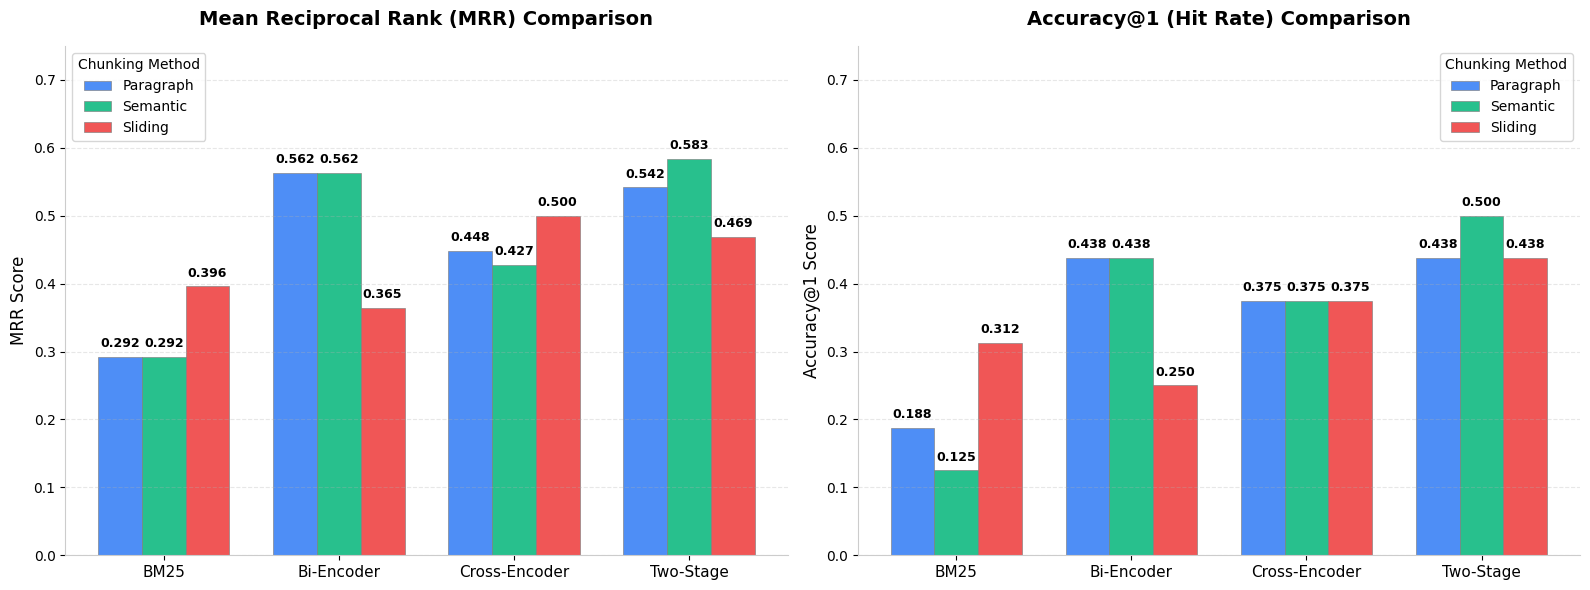

In [46]:
# 2. Vẽ biểu đồ so sánh chất lượng (MRR và Accuracy@1)
plot_overall_quality(df_overall, show=True)

##### 3.3. The trade-off between latency and quality.

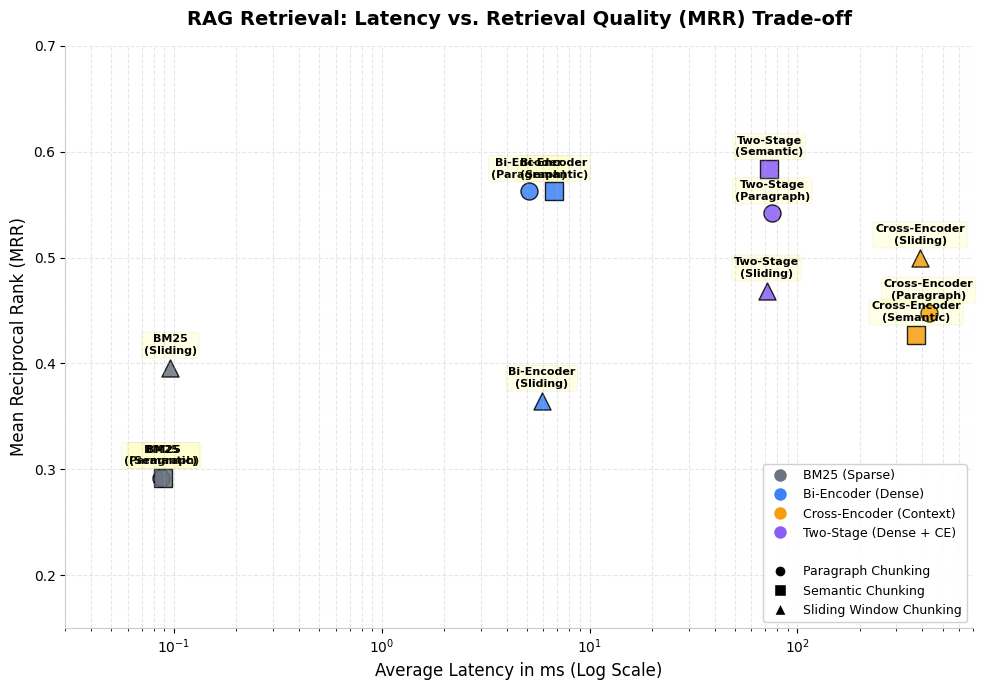

In [47]:
plot_latency_vs_quality(df_overall, show=True)

##### 3.4. Category Breakdown

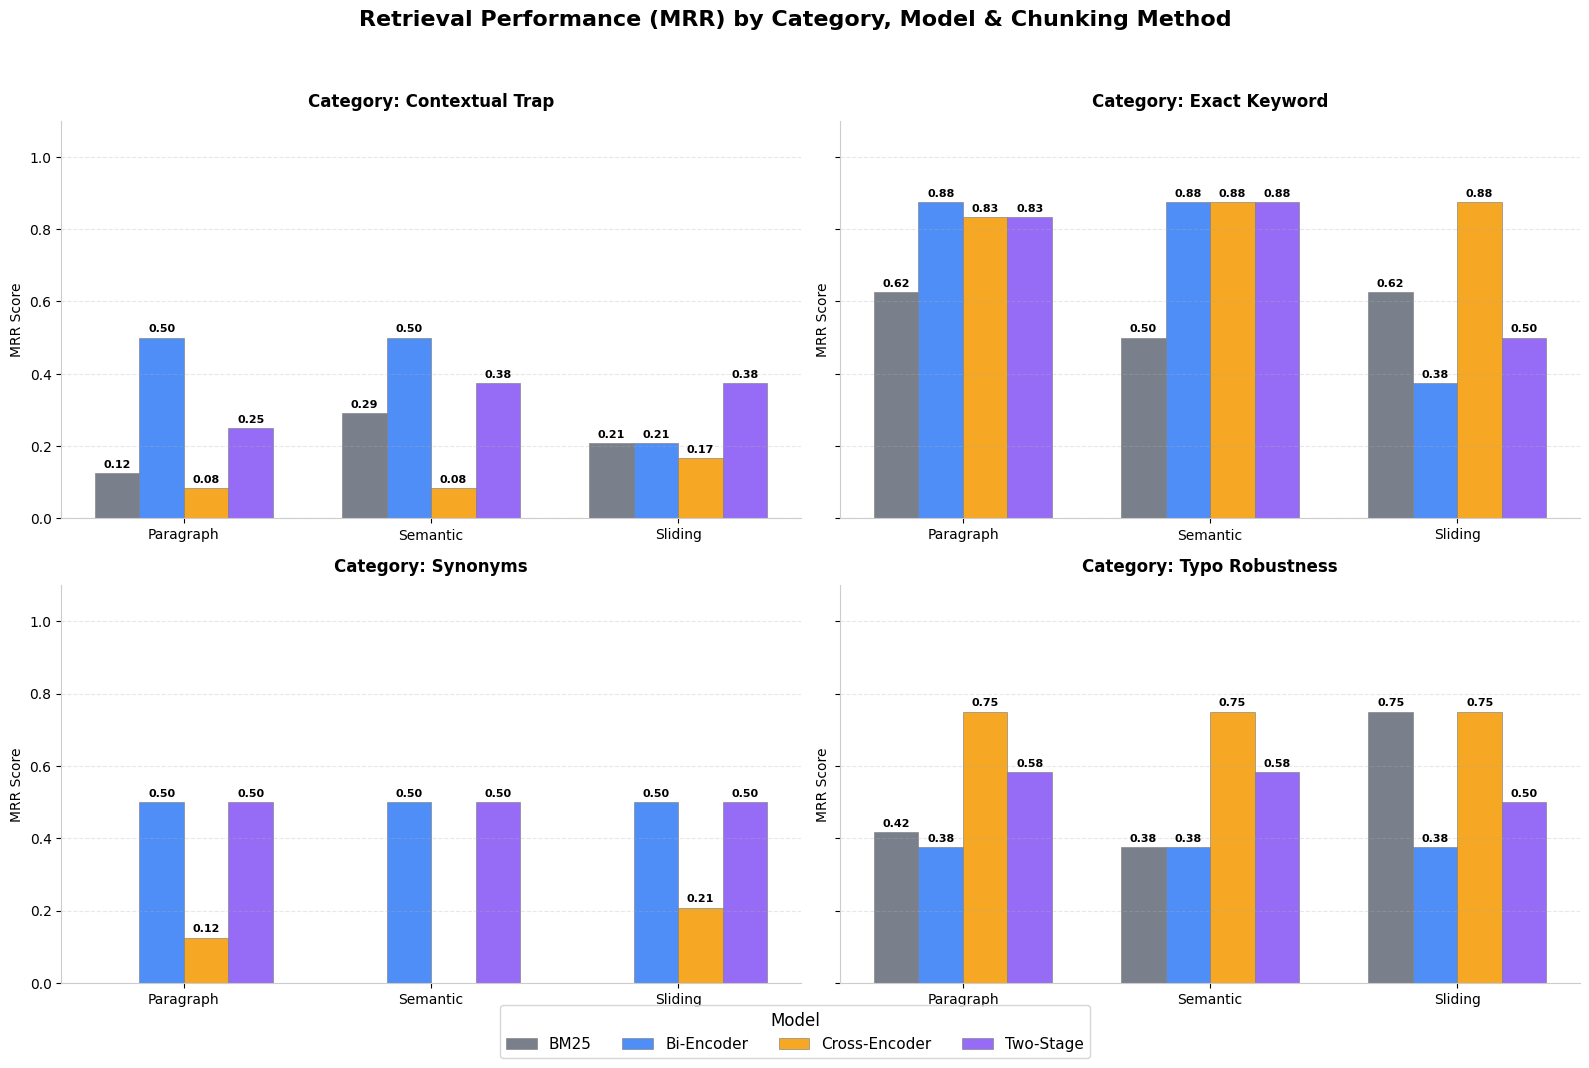

In [48]:
plot_category_breakdown(data_dir="data/evaluation_results", show=True)

#### 3.2. Detail Evaluation

- Sliding chunking

In [63]:
import ast
import json
import os
import pandas as pd

# 1. Đường dẫn tới các file dữ liệu (Hãy đảm bảo tên file chính xác với máy của anh)
detailed_file = "data/evaluation_results/detailed_results_sliding.csv"
chunks_file = "data/chunks_sliding.json"

if not os.path.exists(detailed_file) or not os.path.exists(chunks_file):
    print("Vui lòng kiểm tra lại file detailed_results_semantic.csv hoặc chunks_semantic.json!")
else:
    # 2. Đọc dữ liệu kết quả và dữ liệu chunk văn bản
    df_res = pd.read_csv(detailed_file)
    with open(chunks_file, "r", encoding="utf-8") as f:
        chunks_data = json.load(f)

    # Chuyển đổi list chunks thành một từ điển {Index: Text} để tra cứu nhanh
    chunks_dict = {
        c["index"]: c["text"].replace("\n", " ").strip()
        for c in chunks_data["chunks"]
    }

    # Hàm bổ trợ lấy nội dung văn bản an toàn và rút gọn
    def get_chunk_text(idx_val, max_len=120):
        try:
            idx = int(idx_val)
            if idx in chunks_dict:
                text = chunks_dict[idx]
                return (
                    f"[Idx {idx}] " + text[:max_len] + "..."
                    if len(text) > max_len
                    else f"[Idx {idx}] " + text
                )
            return f"[Idx {idx}] N/A"
        except:
            # Trường hợp Expected_Idx là một list dạng chuỗi '[7, 8]' hoặc rỗng '[]' (Out of Domain)
            try:
                ids = ast.literal_eval(str(idx_val))
                if isinstance(ids, list):
                    if not ids:
                        return "OOD (Không có câu trả lời)"
                    # Lấy text của phần tử đầu tiên trong danh sách expected
                    first_idx = ids[0]
                    text = chunks_dict.get(first_idx, "N/A")
                    return f"[Idx {first_idx}] " + text[:max_len] + "..."
            except:
                pass
            return "N/A"

    # 3. Tạo các cột nội dung văn bản tương ứng cho từng mô hình
    table_data = []

    for _, row in df_res.iterrows():
        # Định dạng trạng thái đúng sai bằng Icon trực quan
        bm25_status = "🟢" if row["BM25_Hit"] == 1.0 else "❌"
        dense_status = "🟢" if row["Dense_Hit"] == 1.0 else "❌"
        ts_status = "🟢" if row["TS_Hit"] == 1.0 else "❌"

        # Nếu là câu hỏi Out of Domain (TC17-TC20), hit=0 nghĩa là Pass bộ lọc (Đúng)
        if row["Category"] == "Out of Domain":
            bm25_status = "🟢 Pass" if row["BM25_Hit"] == 0.0 else "❌ Fail"
            dense_status = "🟢 Pass" if row["Dense_Hit"] == 0.0 else "❌ Fail"
            ts_status = "🟢 Pass" if row["TS_Hit"] == 0.0 else "❌ Fail"

        table_data.append(
            {
                "Mã TC": row["ID"],
                "Nhóm Kiểm Thử": row["Category"],
                "Câu Hỏi (Query)": row["Query"],
                "Văn Bản Đúng (Expected Fragment)": get_chunk_text(
                    row["Expected_Idx"]
                ),
                "Mô hình BM25 (Sparse)": f"{bm25_status} {get_chunk_text(row['BM25_Idx'])}",
                "Mô hình Bi-Encoder (Dense)": f"{dense_status} {get_chunk_text(row['Dense_Idx'])}",
                "Pipeline Two-Stage (Lai)": f"{ts_status} {get_chunk_text(row['TS_Idx'])}",
            }
        )

    # 4. Chuyển đổi sang DataFrame tổng hợp hoàn chỉnh
    df_summary_table = pd.DataFrame(table_data)

    # 5. TỰ ĐỘNG XUẤT RA FILE MARKDOWN ĐỂ COPPY THẲNG VÀO BÁO CÁO WORD
    markdown_file = "data/evaluation_results/details/Detailed_result_sliding.md"
    with open(markdown_file, "w", encoding="utf-8-sig") as md_f:
        md_f.write(
            df_summary_table.to_markdown(index=False, tablefmt="pipe")
        )
    print(f"\n[Thành công] Đã xuất bảng Markdown chi tiết ra file: {markdown_file}")


[Thành công] Đã xuất bảng Markdown chi tiết ra file: data/evaluation_results/details/Detailed_result_sliding.md


- Semantic chunking

In [62]:
import ast
import json
import os
import pandas as pd
from IPython.display import display

# 1. Đường dẫn tới các file dữ liệu (Hãy đảm bảo tên file chính xác với máy của anh)
detailed_file = "data/evaluation_results/detailed_results_semantic.csv"
chunks_file = "data/chunks_semantic.json"

if not os.path.exists(detailed_file) or not os.path.exists(chunks_file):
    print("Vui lòng kiểm tra lại file detailed_results_semantic.csv hoặc chunks_semantic.json!")
else:
    # 2. Đọc dữ liệu kết quả và dữ liệu chunk văn bản
    df_res = pd.read_csv(detailed_file)
    with open(chunks_file, "r", encoding="utf-8") as f:
        chunks_data = json.load(f)

    # Chuyển đổi list chunks thành một từ điển {Index: Text} để tra cứu nhanh
    chunks_dict = {
        c["index"]: c["text"].replace("\n", " ").strip()
        for c in chunks_data["chunks"]
    }

    # Hàm bổ trợ lấy nội dung văn bản an toàn và rút gọn
    def get_chunk_text(idx_val, max_len=120):
        try:
            idx = int(idx_val)
            if idx in chunks_dict:
                text = chunks_dict[idx]
                return (
                    f"[Idx {idx}] " + text[:max_len] + "..."
                    if len(text) > max_len
                    else f"[Idx {idx}] " + text
                )
            return f"[Idx {idx}] N/A"
        except:
            # Trường hợp Expected_Idx là một list dạng chuỗi '[7, 8]' hoặc rỗng '[]' (Out of Domain)
            try:
                ids = ast.literal_eval(str(idx_val))
                if isinstance(ids, list):
                    if not ids:
                        return "OOD (Không có câu trả lời)"
                    # Lấy text của phần tử đầu tiên trong danh sách expected
                    first_idx = ids[0]
                    text = chunks_dict.get(first_idx, "N/A")
                    return f"[Idx {first_idx}] " + text[:max_len] + "..."
            except:
                pass
            return "N/A"

    # 3. Tạo các cột nội dung văn bản tương ứng cho từng mô hình
    table_data = []

    for _, row in df_res.iterrows():
        # Định dạng trạng thái đúng sai bằng Icon trực quan
        bm25_status = "🟢" if row["BM25_Hit"] == 1.0 else "❌"
        dense_status = "🟢" if row["Dense_Hit"] == 1.0 else "❌"
        ts_status = "🟢" if row["TS_Hit"] == 1.0 else "❌"

        # Nếu là câu hỏi Out of Domain (TC17-TC20), hit=0 nghĩa là Pass bộ lọc (Đúng)
        if row["Category"] == "Out of Domain":
            bm25_status = "🟢 Pass" if row["BM25_Hit"] == 0.0 else "❌ Fail"
            dense_status = "🟢 Pass" if row["Dense_Hit"] == 0.0 else "❌ Fail"
            ts_status = "🟢 Pass" if row["TS_Hit"] == 0.0 else "❌ Fail"

        table_data.append(
            {
                "Mã TC": row["ID"],
                "Nhóm Kiểm Thử": row["Category"],
                "Câu Hỏi (Query)": row["Query"],
                "Văn Bản Đúng (Expected Fragment)": get_chunk_text(
                    row["Expected_Idx"]
                ),
                "Mô hình BM25 (Sparse)": f"{bm25_status} {get_chunk_text(row['BM25_Idx'])}",
                "Mô hình Bi-Encoder (Dense)": f"{dense_status} {get_chunk_text(row['Dense_Idx'])}",
                "Pipeline Two-Stage (Lai)": f"{ts_status} {get_chunk_text(row['TS_Idx'])}",
            }
        )

    # 4. Chuyển đổi sang DataFrame tổng hợp hoàn chỉnh
    df_summary_table = pd.DataFrame(table_data)

    # 5. TỰ ĐỘNG XUẤT RA FILE MARKDOWN ĐỂ COPPY THẲNG VÀO BÁO CÁO WORD
    markdown_file = "data/evaluation_results/details/Detailed_result_semantic.md"
    with open(markdown_file, "w", encoding="utf-8-sig") as md_f:
        md_f.write(
            df_summary_table.to_markdown(index=False, tablefmt="pipe")
        )
    print(f"\n[Thành công] Đã xuất bảng Markdown chi tiết ra file: {markdown_file}")


[Thành công] Đã xuất bảng Markdown chi tiết ra file: data/evaluation_results/details/Detailed_result_semantic.md


- Detailed results of paragraph chunking

In [64]:
import ast
import json
import os
import pandas as pd
from IPython.display import display

# 1. Đường dẫn tới các file dữ liệu (Hãy đảm bảo tên file chính xác với máy của anh)
detailed_file = "data/evaluation_results/detailed_results_paragraph.csv"
chunks_file = "data/chunks_paragraph.json"

if not os.path.exists(detailed_file) or not os.path.exists(chunks_file):
    print("Vui lòng kiểm tra lại file detailed_results_paragraph.csv hoặc chunks_paragraph.json!")
else:
    # 2. Đọc dữ liệu kết quả và dữ liệu chunk văn bản
    df_res = pd.read_csv(detailed_file)
    with open(chunks_file, "r", encoding="utf-8") as f:
        chunks_data = json.load(f)

    # Chuyển đổi list chunks thành một từ điển {Index: Text} để tra cứu nhanh
    chunks_dict = {
        c["index"]: c["text"].replace("\n", " ").strip()
        for c in chunks_data["chunks"]
    }

    # Hàm bổ trợ lấy nội dung văn bản an toàn và rút gọn
    def get_chunk_text(idx_val, max_len=120):
        try:
            idx = int(idx_val)
            if idx in chunks_dict:
                text = chunks_dict[idx]
                return (
                    f"[Idx {idx}] " + text[:max_len] + "..."
                    if len(text) > max_len
                    else f"[Idx {idx}] " + text
                )
            return f"[Idx {idx}] N/A"
        except:
            # Trường hợp Expected_Idx là một list dạng chuỗi '[7, 8]' hoặc rỗng '[]' (Out of Domain)
            try:
                ids = ast.literal_eval(str(idx_val))
                if isinstance(ids, list):
                    if not ids:
                        return "OOD (Không có câu trả lời)"
                    # Lấy text của phần tử đầu tiên trong danh sách expected
                    first_idx = ids[0]
                    text = chunks_dict.get(first_idx, "N/A")
                    return f"[Idx {first_idx}] " + text[:max_len] + "..."
            except:
                pass
            return "N/A"

    # 3. Tạo các cột nội dung văn bản tương ứng cho từng mô hình
    table_data = []

    for _, row in df_res.iterrows():
        # Định dạng trạng thái đúng sai bằng Icon trực quan
        bm25_status = "🟢" if row["BM25_Hit"] == 1.0 else "❌"
        dense_status = "🟢" if row["Dense_Hit"] == 1.0 else "❌"
        ts_status = "🟢" if row["TS_Hit"] == 1.0 else "❌"

        # Nếu là câu hỏi Out of Domain (TC17-TC20), hit=0 nghĩa là Pass bộ lọc (Đúng)
        if row["Category"] == "Out of Domain":
            bm25_status = "🟢 Pass" if row["BM25_Hit"] == 0.0 else "❌ Fail"
            dense_status = "🟢 Pass" if row["Dense_Hit"] == 0.0 else "❌ Fail"
            ts_status = "🟢 Pass" if row["TS_Hit"] == 0.0 else "❌ Fail"

        table_data.append(
            {
                "Mã TC": row["ID"],
                "Nhóm Kiểm Thử": row["Category"],
                "Câu Hỏi (Query)": row["Query"],
                "Văn Bản Đúng (Expected Fragment)": get_chunk_text(
                    row["Expected_Idx"]
                ),
                "Mô hình BM25 (Sparse)": f"{bm25_status} {get_chunk_text(row['BM25_Idx'])}",
                "Mô hình Bi-Encoder (Dense)": f"{dense_status} {get_chunk_text(row['Dense_Idx'])}",
                "Pipeline Two-Stage (Lai)": f"{ts_status} {get_chunk_text(row['TS_Idx'])}",
            }
        )

    # 4. Chuyển đổi sang DataFrame tổng hợp hoàn chỉnh
    df_summary_table = pd.DataFrame(table_data)

    # 5. TỰ ĐỘNG XUẤT RA FILE MARKDOWN ĐỂ COPPY THẲNG VÀO BÁO CÁO WORD
    markdown_file = "data/evaluation_results/details/Detailed_result_paragraph.md"
    with open(markdown_file, "w", encoding="utf-8-sig") as md_f:
        md_f.write(
            df_summary_table.to_markdown(index=False, tablefmt="pipe")
        )
    print(f"\n[Thành công] Đã xuất bảng Markdown chi tiết ra file: {markdown_file}")


[Thành công] Đã xuất bảng Markdown chi tiết ra file: data/evaluation_results/details/Detailed_result_paragraph.md


### 4. Conclusion

The project conducted comprehensive testing and evaluation of four query models (**BM25**, **Bi-Encoder**, **Cross-Encoder Single-Stage**, and **Two-Stage Retrieval**) combined with three text fragmentation techniques (**Paragraph Chunking**, **Semantic Chunking by Sentence**, and **Sliding Window**) on a test dataset simulating real-world challenges.

From the experimental results, the research team drew the following important conclusions:

---

#### 4.1. Key Findings

1. Chunking plays a decisive role in Reranking quality
   * Semantic Chunking (by sentence) showed the most outstanding performance when preserving the complete sentence structure and boundaries. This method helped the Two-Stage model reach peak performance with MRR = 0.625 and Accuracy@1 = 56.2%.

   * Sliding Window (mechanical word cutting) caused a significant degradation in quality for models using the full attention mechanism (Cross-Encoder). Specifically, the MRR of the Two-Stage model decreased from 0.625 (Semantic) to 0.406 (Sliding Window) (a decrease of approximately 35%).

   * Reason: Mechanical word cutting breaks the sentence midway, disrupting grammatical connections and interfering with the Self-Attention mechanism of the Cross-Encoder when trying to assess the correlation between the question and the missing passage.

2. Distinct Differences Between Query Models
   * BM25 (Sparse Model): Has the fastest processing speed (<0.1ms) but very low accuracy (12.5% ​​Accuracy@1). BM25 completely fails against questions using synonyms (*Synonyms* with MRR = 0.0) and contextual traps (*Contextual Trap*) because it only matches exact keywords.

   * Bi-Encoder (Dense Model - `all-MiniLM-L6-v2`): Offers a significant improvement in semantics (MRR increased to 0.552), handles synonym queries and contextual traps well with optimal latency (6-12ms). However, this model still struggles with questions containing spelling errors (*Typo Robustness* achieves Accuracy@1 at only 25%).

   * Cross-Encoder (Single-Stage): Achieves deep contextual understanding and high accuracy in spell-checking challenges (Accuracy@1 reaches 75%). However, calculating attention across the entire corpus results in excessively slow response times (~340ms), making it impractical for real-world production environments.

3. The Optimality of Two-Stage Architecture (Bi-Encoder + Cross-Encoder Reranker)
   * Two-Stage is the most optimal model, lying on the Pareto frontier (the best trade-off between Latency and Quality).

   * By using Bi-Encoder to quickly filter the top 5 candidates, and then using only Cross-Encoder to rerank these 5 candidates, Two-Stage RAG achieves the highest accuracy (MRR = 0.625 with Semantic Chunking) but the total latency is only ~70ms (5 times faster than Cross-Encoder Single-Stage).

---

#### 4.2. RAG System Design Recommendations (Architecture Recommendations)

To build an optimal RAG system for production, we propose the following recommendations:

1. **Regarding Data Processing (Chunking):** Prioritize using Semantic Chunking (by sentence) or Paragraph Chunking (if the original text structure is very clearly segmented). Absolutely avoid using traditional *Sliding Window* if there is a Reranker step afterwards.

2. **Regarding Query Architecture (Retriever):** Implementing a **Two-Stage Retrieval** model:

   * Stage 1 (Retrieval): Uses Dense Retriever (`all-MiniLM-L6-v2`) to quickly retrieve the Top 5 or Top 10 best candidate chunks.

   * Stage 2 (Reranking): Uses Cross-Encoder (`ms-marco-MiniLM-L-6-v2`) to re-rank the priority of those Top 5 chunks before sending them as context to the LLM.